In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Folder Structure + Train/Val/Test Split**

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# -------------------------------
# PATHS
# -------------------------------
ORIGINAL_DATASET = "/content/drive/MyDrive/datasets/eurosat_raw/EuroSAT"
OUTPUT_BASE = "/content/drive/MyDrive/datasets/eurosat_split_final"

TRAIN_DIR = os.path.join(OUTPUT_BASE, "train")
VAL_DIR   = os.path.join(OUTPUT_BASE, "val")
TEST_DIR  = os.path.join(OUTPUT_BASE, "test")

# -------------------------------
# CLEAN OLD SPLIT FOLDER
# -------------------------------
if os.path.exists(OUTPUT_BASE):
    shutil.rmtree(OUTPUT_BASE)

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

# -------------------------------
# DETECT ONLY VALID IMAGE CLASSES
# -------------------------------
valid_ext = (".jpg", ".jpeg", ".png", ".tif", ".tiff")

classes = []
for folder in sorted(os.listdir(ORIGINAL_DATASET)):
    full_path = os.path.join(ORIGINAL_DATASET, folder)
    if os.path.isdir(full_path):
        # check if folder contains at least 1 image
        has_image = any(f.lower().endswith(valid_ext) for f in os.listdir(full_path))
        if has_image:
            classes.append(folder)

print("Detected classes:", classes)
print("Total:", len(classes))

# -------------------------------
# SPLIT DATASET WITH SAFETY
# -------------------------------
class_counts = {}

for cls in tqdm(classes, desc="Splitting Classes", ncols=120):

    src_folder = os.path.join(ORIGINAL_DATASET, cls)

    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(valid_ext)]

    # skip empty folders
    if len(images) == 0:
        continue

    class_counts[cls] = len(images)

    # Train: 70%
    train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
    # Val: 15%  Test: 15%
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=42)

    # create class folders only when images exist
    os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, cls), exist_ok=True)

    # copy files
    for img in train_imgs:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(TRAIN_DIR, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(VAL_DIR, cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(TEST_DIR, cls, img))


# -------------------------------
# SUMMARY REPORT
# -------------------------------
print("\n✅ Dataset Splitting Completed Successfully!\n")

def count_imgs(path):
    count = 0
    for r, d, files in os.walk(path):
        for f in files:
            if f.lower().endswith(valid_ext):
                count += 1
    return count

total_original = sum(class_counts.values())

print(f" Total Original Images: {total_original}\n")

print("📊 Images per Class:")
for cls, count in class_counts.items():
    print(f" - {cls}: {count}")

print("\n📁 Final Split Totals:")
print(" Train:", count_imgs(TRAIN_DIR))
print(" Val:  ", count_imgs(VAL_DIR))
print(" Test: ", count_imgs(TEST_DIR))

print("\n Ready for Training!")


**0. Install & Imports**

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
import timm
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image
import torch.nn.functional as F
import random


Convnext Model training and Testing:

In [ ]:
import os
import torch
import torch.nn as nn
from torch.backends import cudnn
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import timm

# ============================
# 1. PATHS
# ============================
BASE_DIR  = "/content/drive/MyDrive/datasets/eurosat_split_final"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# ============================
# 2. CONFIG
# ============================
IMAGE_SIZE = 224
BATCH_SIZE = 16
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cudnn.benchmark = True
print("Using device:", device)

# ============================
# 3. TRANSFORMS
# ============================
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ============================
# 4. DATASETS & LOADERS
# ============================
train_ds = ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = ImageFolder(VAL_DIR,   transform=test_tf)
test_ds  = ImageFolder(TEST_DIR,  transform=test_tf)

classes = train_ds.classes
num_classes = len(classes)
print("Classes:", classes)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

criterion = nn.CrossEntropyLoss()

# ============================
# 5. LOAD SAVED CONVNEXT MODEL
# ============================
MODEL_PATH = "//content/drive/MyDrive/EuroSAT_Models/ConvNeXt_BASE_EuroSAT.pth"   # <-- change if needed

model = timm.create_model("convnext_base", pretrained=False, num_classes=num_classes)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("ConvNeXt model loaded successfully from Drive!")

# ============================
# 6. TEST SET ACCURACY
# ============================
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n🎯 Test Accuracy on NEW test split: {accuracy:.2f}%")


In [ ]:
import numpy as np

HISTORY_PATH = "/content/drive/MyDrive/EuroSAT_Models/ConvNeXt_HISTORY.npy"

history = np.load(HISTORY_PATH, allow_pickle=True).item()

print("===== TRAINING & VALIDATION RESULTS =====\n")

epochs = len(history["train_loss"])

for i in range(epochs):
    print(f"🔵 Epoch {i+1}/{epochs}")
    print(f"Train Loss: {history['train_loss'][i]:.4f}  |  Train Acc: {history['train_acc'][i]:.4f}")
    print(f"Val Loss:   {history['val_loss'][i]:.4f}  |  Val Acc:   {history['val_acc'][i]:.4f}")
    print("-------------------------------------------------\n")

# ===== PRINT TEST METRICS =====
if "test_loss" in history and "test_acc" in history:
    print("===== TEST RESULTS =====")
    print(f"Test Loss:     {history['test_loss']:.4f}")
    print(f"Test Accuracy: {history['test_acc']:.4f}")
else:
    print("⚠️ Test metrics not found in HISTORY file.")


===== TRAINING & VALIDATION RESULTS =====

🔵 Epoch 1/5
Train Loss: 0.1844  |  Train Acc: 0.9394
Val Loss:   0.1120  |  Val Acc:   0.9649
-------------------------------------------------

🔵 Epoch 2/5
Train Loss: 0.0735  |  Train Acc: 0.9765
Val Loss:   0.1190  |  Val Acc:   0.9607
-------------------------------------------------

🔵 Epoch 3/5
Train Loss: 0.0633  |  Train Acc: 0.9787
Val Loss:   0.0673  |  Val Acc:   0.9773
-------------------------------------------------

🔵 Epoch 4/5
Train Loss: 0.0472  |  Train Acc: 0.9849
Val Loss:   0.0508  |  Val Acc:   0.9815
-------------------------------------------------

🔵 Epoch 5/5
Train Loss: 0.0405  |  Train Acc: 0.9875
Val Loss:   0.0763  |  Val Acc:   0.9746
-------------------------------------------------

===== TEST RESULTS =====
Test Loss:     0.0708
Test Accuracy: 0.9753


Model Load for evaluation Matrices and Prediction:

In [ ]:
# =========================
# CELL 1: SETUP + LOADING
# =========================
import os, random, numpy as np
import torch
import torch.nn as nn
import timm

from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

# ------ PATHS ------
MODEL_PATH = "/content/drive/MyDrive/EuroSAT_Models/ConvNeXt_BASE_EuroSAT.pth"
TEST_DIR   = "/content/drive/MyDrive/datasets/eurosat_split_final/test"

# ------ CLASSES ------
classes = [
    "AnnualCrop","Forest","HerbVeg","Highway","Industrial",
    "Pasture","PermCrop","Residential","River","SeaLake"
]

# ------ DEVICE ------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------ TRANSFORMS ------
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ------ DATASET + DATALOADER ------
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
print("Test images:", len(test_ds))
print("Classes:", test_ds.classes)

# ------ LOAD MODEL ------
model = timm.create_model(
    "convnext_base",
    pretrained=False,
    num_classes=len(classes)
)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

print("✔ ConvNeXt model loaded and ready.")


Using device: cuda
Test images: 4050
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
✔ ConvNeXt model loaded and ready.


Evaluation Matrices:

In [ ]:
# =========================
# CELL 2: EVALUATION METRICS
# =========================
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

all_labels = []
all_preds  = []
all_probs  = []
test_loss  = 0.0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_loss /= len(test_ds)

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

metrics = {}
metrics["Accuracy"]                   = accuracy_score(y_true, y_pred)
metrics["Balanced Accuracy"]          = balanced_accuracy_score(y_true, y_pred)
metrics["Weighted Balanced Accuracy"] = recall_score(y_true, y_pred, average="weighted")

metrics["Precision (Macro)"]    = precision_score(y_true, y_pred, average="macro",   zero_division=0)
metrics["Precision (Micro)"]    = precision_score(y_true, y_pred, average="micro",   zero_division=0)
metrics["Precision (Weighted)"] = precision_score(y_true, y_pred, average="weighted",zero_division=0)

metrics["Recall (Macro)"]       = recall_score(y_true, y_pred, average="macro",   zero_division=0)
metrics["Recall (Micro)"]       = recall_score(y_true, y_pred, average="micro",   zero_division=0)
metrics["Recall (Weighted)"]    = recall_score(y_true, y_pred, average="weighted",zero_division=0)

metrics["F1 (Macro)"]           = f1_score(y_true, y_pred, average="macro",   zero_division=0)
metrics["F1 (Micro)"]           = f1_score(y_true, y_pred, average="micro",   zero_division=0)
metrics["F1 (Weighted)"]        = f1_score(y_true, y_pred, average="weighted",zero_division=0)

metrics["Cross Entropy"]        = test_loss
metrics["MCC"]                  = matthews_corrcoef(y_true, y_pred)
metrics["Cohen Kappa"]          = cohen_kappa_score(y_true, y_pred)

print("===== CONVNEXT TEST EVALUATION =====")
for k, v in metrics.items():
    print(f"{k:25s}: {v:.6f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))




===== CONVNEXT TEST EVALUATION =====
Accuracy                 : 0.975309
Balanced Accuracy        : 0.972267
Weighted Balanced Accuracy: 0.975309
Precision (Macro)        : 0.976929
Precision (Micro)        : 0.975309
Precision (Weighted)     : 0.975796
Recall (Macro)           : 0.972267
Recall (Micro)           : 0.975309
Recall (Weighted)        : 0.975309
F1 (Macro)               : 0.974182
F1 (Micro)               : 0.975309
F1 (Weighted)            : 0.975180
Cross Entropy            : 0.070821
MCC                      : 0.972583
Cohen Kappa              : 0.972507

Classification Report:

              precision    recall  f1-score   support

  AnnualCrop       0.97      0.98      0.98       450
      Forest       0.99      0.99      0.99       450
     HerbVeg       0.94      0.99      0.96       450
     Highway       0.99      0.98      0.99       375
  Industrial       1.00      0.95      0.97       375
     Pasture       0.99      0.91      0.95       300
    PermCrop      

Prediction of Convnext:

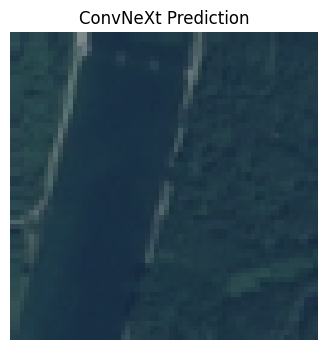

Actual Class:    River
Predicted Class: River

Class Probabilities:
River             : 100.00%
Highway           :   0.00%
Forest            :   0.00%
SeaLake           :   0.00%
AnnualCrop        :   0.00%
Industrial        :   0.00%
Residential       :   0.00%
Pasture           :   0.00%
PermCrop          :   0.00%
HerbVeg           :   0.00%


In [ ]:
# =========================
# CELL 3: RANDOM IMAGE PREDICTION
# =========================
# pick a random sample from test set (using original file path)
img_path, true_label_idx = random.choice(test_ds.samples)
true_class = classes[true_label_idx]

# load image for display
orig_img = Image.open(img_path).convert("RGB")

# preprocess for model
input_tensor = test_tf(orig_img).unsqueeze(0).to(device)

with torch.no_grad():
    out = model(input_tensor)
    prob = torch.softmax(out, dim=1)[0].cpu().numpy()

pred_idx = int(np.argmax(prob))
pred_class = classes[pred_idx]

# show image
plt.figure(figsize=(4,4))
plt.imshow(orig_img)
plt.axis("off")
plt.title("ConvNeXt Prediction")
plt.show()

# print results
print("Actual Class:   ", true_class)
print("Predicted Class:", pred_class)
print("\nClass Probabilities:")
for cls_name, p in sorted(zip(classes, prob), key=lambda x: x[1], reverse=True):
    print(f"{cls_name:18s}: {p*100:6.2f}%")


**Swin Transformmer:**

In [ ]:
# ============================================================
# CELL 1 — SETUP + DATA + MODEL + FUNCTIONS
# ============================================================

import os
import timm
import torch
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# PATHS (EDIT THESE IF NEEDED)
# -----------------------------
TRAIN_DIR = "/content/drive/MyDrive/datasets/eurosat_split_final/test"
VAL_DIR   = "/content/drive/MyDrive/datasets/eurosat_split_final/val"
TEST_DIR  = "/content/drive/MyDrive/datasets/eurosat_split_final/test"

SAVE_DIR  = "//content/drive/MyDrive/EuroSAT_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# HYPERPARAMETERS
# -----------------------------
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 5
IMAGE_SIZE = 224

# -----------------------------
# PREPROCESSING
# -----------------------------
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# -----------------------------
# CLASSES
# -----------------------------
classes = [
    "AnnualCrop","Forest","HerbVeg","Highway","Industrial",
    "Pasture","PermCrop","Residential","River","SeaLake"
]
num_classes = len(classes)

# -----------------------------
# LOAD DATASETS
# -----------------------------
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR, transform=test_tf)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# CREATE SWIN BASE MODEL
# -----------------------------
model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=True,
    num_classes=num_classes
)
model.to(device)

# ============================================================
# TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, return_preds=False):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_preds:
                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

    if return_preds:
        return total_loss / len(loader), correct / total, preds_all, labels_all

    return total_loss / len(loader), correct / total


Device: cuda



🔵 Epoch 1/5


Train Loss: 0.1823 | Train Acc: 0.9405
Val Loss:   0.0996 | Val Acc:   0.9690

🔵 Epoch 2/5


Train Loss: 0.1009 | Train Acc: 0.9667
Val Loss:   0.1418 | Val Acc:   0.9532

🔵 Epoch 3/5


Train Loss: 0.0745 | Train Acc: 0.9763
Val Loss:   0.0974 | Val Acc:   0.9734

🔵 Epoch 4/5


Train Loss: 0.0745 | Train Acc: 0.9746
Val Loss:   0.1162 | Val Acc:   0.9699

🔵 Epoch 5/5


Train Loss: 0.0714 | Train Acc: 0.9770
Val Loss:   0.1389 | Val Acc:   0.9561

🟢 Testing on Test Set...

✅ Test Accuracy: 0.9778

📘 Classification Report:
              precision    recall  f1-score   support

  AnnualCrop       0.96      1.00      0.98       450
      Forest       1.00      1.00      1.00       450
     HerbVeg       0.98      0.99      0.98       450
     Highway       1.00      0.89      0.94       375
  Industrial       0.99      0.94      0.96       375
     Pasture       0.97      0.98      0.98       300
    PermCrop       0.97      0.98      0.97       375
 Residential       0.93      1.00      0.97       450
       River       0.98      1.00      0.99       375
     SeaLake       1.00      1.00      1.00       450

    accuracy                           0.98      4050
   macro avg       0.98      0.98      0.98      4050
weighted avg       0.98      0.98      0.98      4050



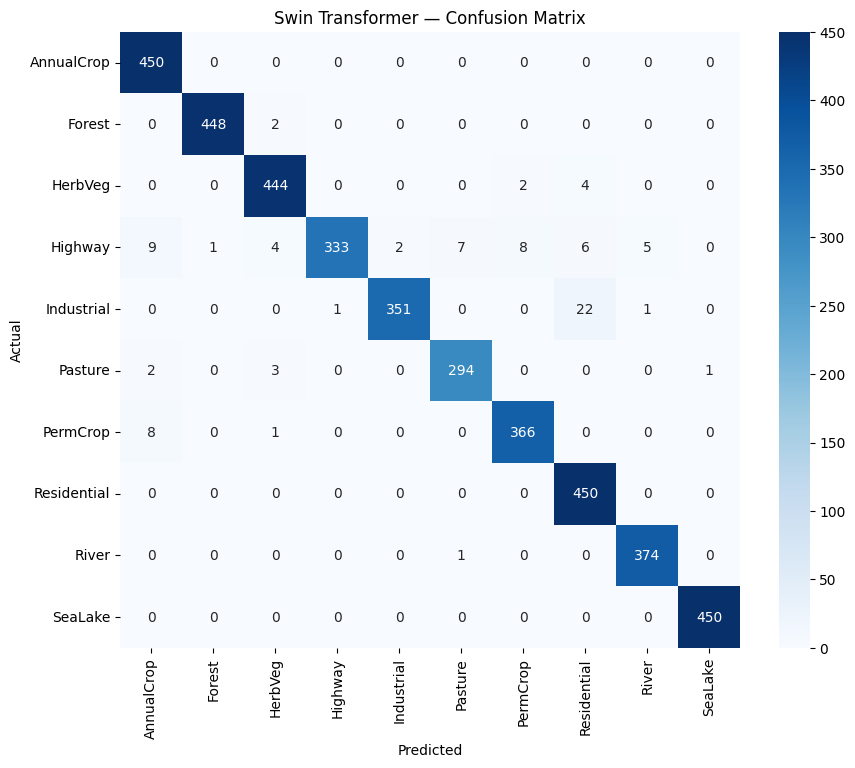


💾 Model + Training History Saved to: //content/drive/MyDrive/EuroSAT_Models


In [ ]:
from tqdm import tqdm

# ============================================================
# CELL 2 — TRAIN → TEST → EVALUATE → SAVE
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}


# -----------------------------
# TRAINING LOOP with PROGRESS BAR
# -----------------------------
for epoch in range(EPOCHS):
    print(f"\n🔵 Epoch {epoch+1}/{EPOCHS}")

    # ---- PROGRESS BAR FOR TRAIN ----
    train_pbar = tqdm(train_loader, desc="Training", leave=False)

    # manually loop to show progress bar
    all_losses = []
    correct = 0
    total = 0

    for images, targets in train_pbar:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        all_losses.append(loss.item())
        _, predicted = outputs.max(1)

        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        train_pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100 * correct/total:.2f}%"
        })

    # compute epoch stats
    tr_loss = sum(all_losses) / len(train_loader)
    tr_acc = correct / total

    # ---- VALIDATION ----
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


# ============================================================
# TESTING
# ============================================================
print("\n🟢 Testing on Test Set...")

test_loss, test_acc, preds, labels = evaluate(
    model, test_loader, criterion, return_preds=True
)

print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print("\n📘 Classification Report:")
print(classification_report(labels, preds, target_names=classes))


# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Swin Transformer — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# SAVE MODEL + HISTORY
# ============================================================
torch.save(
    model.state_dict(),
    os.path.join(SAVE_DIR, "Swin_BASE_EuroSAT.pth")
)

np.save(
    os.path.join(SAVE_DIR, "Swin_BASE_EuroSAT_HISTORY.npy"),
    history,
    allow_pickle=True
)

print("\n💾 Model + Training History Saved to:", SAVE_DIR)


**Load Model for Evalustion Matrices and Prediction:**

In [ ]:
# =========================
# CELL 1: SWIN SETUP + LOADING
# =========================
import os, random, numpy as np
import torch
import torch.nn as nn
import timm

from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

# ------ PATHS ------
SWIN_MODEL_PATH = "/content/drive/MyDrive/EuroSAT_Models/Swin_BASE_EuroSAT.pth"
TEST_DIR        = "/content/drive/MyDrive/datasets/eurosat_split_final/test"

# ------ CLASSES ------
classes = [
    "AnnualCrop","Forest","HerbVeg","Highway","Industrial",
    "Pasture","PermCrop","Residential","River","SeaLake"
]

# ------ DEVICE ------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------ TRANSFORMS ------
swin_test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ------ DATASET + DATALOADER ------
swin_test_ds = datasets.ImageFolder(TEST_DIR, transform=swin_test_tf)
swin_test_loader = DataLoader(swin_test_ds, batch_size=32, shuffle=False)
print("Test images:", len(swin_test_ds))
print("Classes:", swin_test_ds.classes)

# ------ LOAD SWIN MODEL ------
swin_model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=False,
    num_classes=len(classes)
)

swin_state = torch.load(SWIN_MODEL_PATH, map_location=device)
swin_model.load_state_dict(swin_state)
swin_model.to(device)
swin_model.eval()

swin_criterion = nn.CrossEntropyLoss()

print("✔ Swin Transformer model loaded and ready.")


Using device: cuda
Test images: 4050
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
✔ Swin Transformer model loaded and ready.


**Evaluation Matrices:**

In [ ]:
# =========================
# CELL 2: SWIN EVALUATION METRICS
# =========================
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

swin_all_labels = []
swin_all_preds  = []
swin_all_probs  = []
swin_test_loss  = 0.0

swin_model.eval()
with torch.no_grad():
    for images, labels in swin_test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = swin_model(images)
        loss = swin_criterion(outputs, labels)
        swin_test_loss += loss.item() * images.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        swin_all_labels.extend(labels.cpu().numpy())
        swin_all_preds.extend(preds.cpu().numpy())
        swin_all_probs.extend(probs.cpu().numpy())

swin_test_loss /= len(swin_test_ds)

swin_y_true = np.array(swin_all_labels)
swin_y_pred = np.array(swin_all_preds)
swin_y_prob = np.array(swin_all_probs)

swin_metrics = {}
swin_metrics["Accuracy"]                   = accuracy_score(swin_y_true, swin_y_pred)
swin_metrics["Balanced Accuracy"]          = balanced_accuracy_score(swin_y_true, swin_y_pred)
swin_metrics["Weighted Balanced Accuracy"] = recall_score(swin_y_true, swin_y_pred, average="weighted")

swin_metrics["Precision (Macro)"]    = precision_score(swin_y_true, swin_y_pred, average="macro",   zero_division=0)
swin_metrics["Precision (Micro)"]    = precision_score(swin_y_true, swin_y_pred, average="micro",   zero_division=0)
swin_metrics["Precision (Weighted)"] = precision_score(swin_y_true, swin_y_pred, average="weighted",zero_division=0)

swin_metrics["Recall (Macro)"]       = recall_score(swin_y_true, swin_y_pred, average="macro",   zero_division=0)
swin_metrics["Recall (Micro)"]       = recall_score(swin_y_true, swin_y_pred, average="micro",   zero_division=0)
swin_metrics["Recall (Weighted)"]    = recall_score(swin_y_true, swin_y_pred, average="weighted",zero_division=0)

swin_metrics["F1 (Macro)"]           = f1_score(swin_y_true, swin_y_pred, average="macro",   zero_division=0)
swin_metrics["F1 (Micro)"]           = f1_score(swin_y_true, swin_y_pred, average="micro",   zero_division=0)
swin_metrics["F1 (Weighted)"]        = f1_score(swin_y_true, swin_y_pred, average="weighted",zero_division=0)

swin_metrics["Cross Entropy"]        = swin_test_loss
swin_metrics["MCC"]                  = matthews_corrcoef(swin_y_true, swin_y_pred)
swin_metrics["Cohen Kappa"]          = cohen_kappa_score(swin_y_true, swin_y_pred)

print("===== SWIN TEST EVALUATION =====")
for k, v in swin_metrics.items():
    print(f"{k:25s}: {v:.6f}")

print("\nClassification Report:\n")
print(classification_report(swin_y_true, swin_y_pred, target_names=classes))



===== SWIN TEST EVALUATION =====
Accuracy                 : 0.977778
Balanced Accuracy        : 0.975956
Weighted Balanced Accuracy: 0.977778
Precision (Macro)        : 0.978909
Precision (Micro)        : 0.977778
Precision (Weighted)     : 0.978492
Recall (Macro)           : 0.975956
Recall (Micro)           : 0.977778
Recall (Weighted)        : 0.977778
F1 (Macro)               : 0.976865
F1 (Micro)               : 0.977778
F1 (Weighted)            : 0.977581
Cross Entropy            : 0.067245
MCC                      : 0.975380
Cohen Kappa              : 0.975261

Classification Report:

              precision    recall  f1-score   support

  AnnualCrop       0.96      1.00      0.98       450
      Forest       1.00      1.00      1.00       450
     HerbVeg       0.98      0.99      0.98       450
     Highway       1.00      0.89      0.94       375
  Industrial       0.99      0.94      0.96       375
     Pasture       0.97      0.98      0.98       300
    PermCrop       0.9

Prediction of Swin Transformmer:

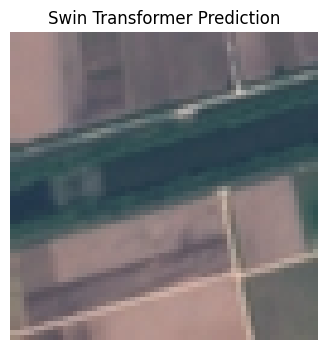

Actual Class:    River
Predicted Class: River

Class Probabilities:
River             :  99.96%
AnnualCrop        :   0.02%
Highway           :   0.01%
PermCrop          :   0.01%
SeaLake           :   0.01%
HerbVeg           :   0.00%
Industrial        :   0.00%
Pasture           :   0.00%
Residential       :   0.00%
Forest            :   0.00%


In [ ]:
# =========================
# CELL 3: SWIN RANDOM IMAGE PREDICTION
# =========================
# pick a random sample from Swin test set
img_path, true_label_idx = random.choice(swin_test_ds.samples)
true_class = classes[true_label_idx]

# load image for display
orig_img = Image.open(img_path).convert("RGB")

# preprocess for model
input_tensor = swin_test_tf(orig_img).unsqueeze(0).to(device)

with torch.no_grad():
    out = swin_model(input_tensor)
    prob = torch.softmax(out, dim=1)[0].cpu().numpy()

pred_idx = int(np.argmax(prob))
pred_class = classes[pred_idx]

# show image
plt.figure(figsize=(4,4))
plt.imshow(orig_img)
plt.axis("off")
plt.title("Swin Transformer Prediction")
plt.show()

# print results
print("Actual Class:   ", true_class)
print("Predicted Class:", pred_class)
print("\nClass Probabilities:")
for cls_name, p in sorted(zip(classes, prob), key=lambda x: x[1], reverse=True):
    print(f"{cls_name:18s}: {p*100:6.2f}%")


**Graphs:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ConvNeXt history
conv_hist = np.load("/content/drive/MyDrive/EuroSAT_Models/ConvNeXt_HISTORY.npy", allow_pickle=True).item()

# Swin history
swin_hist = np.load("/content/drive/MyDrive/EuroSAT_Models/Swin_BASE_EuroSAT_HISTORY.npy", allow_pickle=True).item()

# ConvNeXt metrics (set these from your printed values)
conv_metrics = {
    "Accuracy": 0.975309,
    "Balanced Accuracy": 0.972267,
    "Precision Macro": 0.976929,
    "Recall Macro": 0.972267,
    "F1 Macro": 0.974182,
    "F1 Weighted": 0.975180,
    "MCC": 0.972583,
    "Kappa": 0.972507
}

# Swin metrics
swin_metrics = {
    "Accuracy": 0.977778,
    "Balanced Accuracy": 0.975956,
    "Precision Macro": 0.978909,
    "Recall Macro": 0.975956,
    "F1 Macro": 0.976865,
    "F1 Weighted": 0.977581,
    "MCC": 0.975380,
    "Kappa": 0.975261
}

# Per-class metrics (from classification reports)
conv_precision = [0.97,0.99,0.94,0.99,1.00,0.99,0.96,0.95,0.98,0.99]
conv_recall    = [0.98,0.99,0.99,0.98,0.95,0.91,0.93,1.00,0.99,1.00]
conv_f1        = [0.98,0.99,0.96,0.99,0.97,0.95,0.95,0.98,0.99,0.99]

swin_precision = [0.96,1.00,0.98,1.00,0.99,0.97,0.97,0.93,0.98,1.00]
swin_recall    = [1.00,1.00,0.99,0.89,0.94,0.98,0.98,1.00,1.00,1.00]
swin_f1        = [0.98,1.00,0.98,0.94,0.96,0.98,0.97,0.97,0.99,1.00]

classes = [
    "AnnualCrop","Forest","HerbVeg","Highway","Industrial",
    "Pasture","PermCrop","Residential","River","SeaLake"
]


**Combined Training & Validation Accuracy Graph**

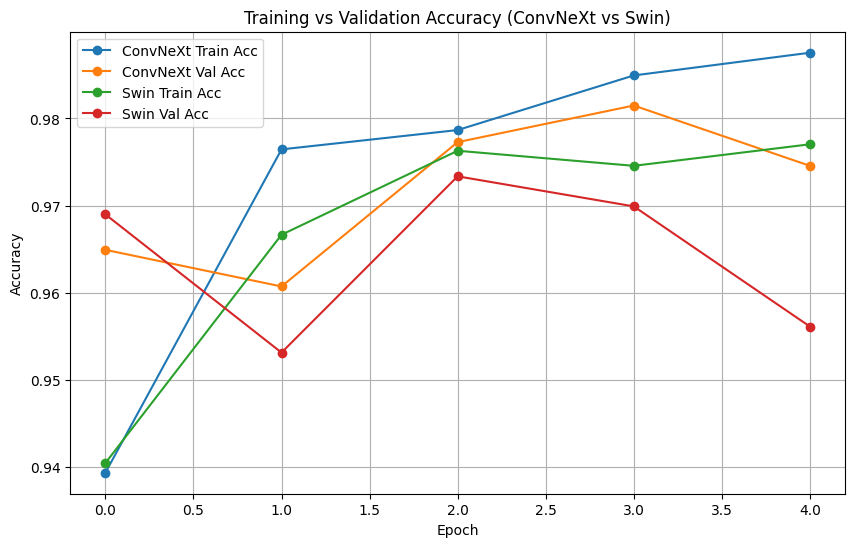

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(conv_hist["train_acc"], marker='o', label="ConvNeXt Train Acc")
plt.plot(conv_hist["val_acc"], marker='o', label="ConvNeXt Val Acc")
plt.plot(swin_hist["train_acc"], marker='o', label="Swin Train Acc")
plt.plot(swin_hist["val_acc"], marker='o', label="Swin Val Acc")

plt.title("Training vs Validation Accuracy (ConvNeXt vs Swin)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


**Combined Training & Validation Loss Graph**

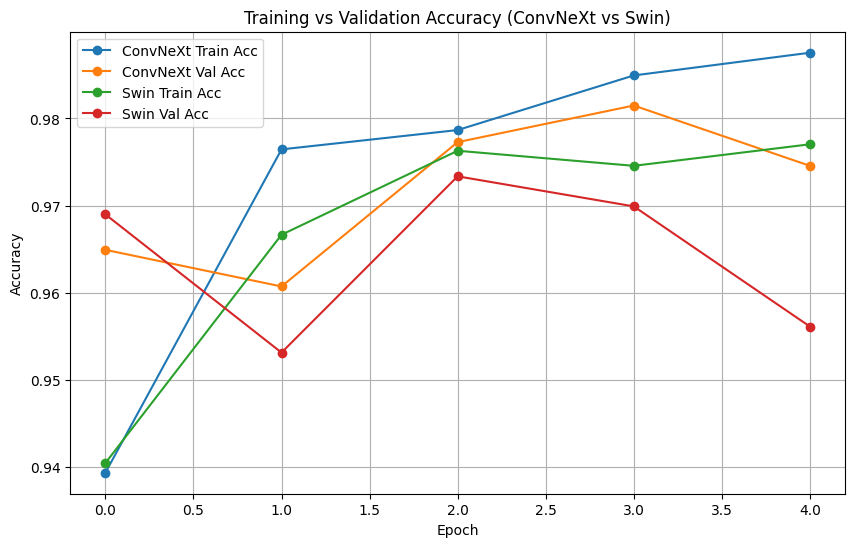

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(conv_hist["train_acc"], marker='o', label="ConvNeXt Train Acc")
plt.plot(conv_hist["val_acc"], marker='o', label="ConvNeXt Val Acc")
plt.plot(swin_hist["train_acc"], marker='o', label="Swin Train Acc")
plt.plot(swin_hist["val_acc"], marker='o', label="Swin Val Acc")

plt.title("Training vs Validation Accuracy (ConvNeXt vs Swin)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


**ConvNeXt vs Swin: Test Accuracy**

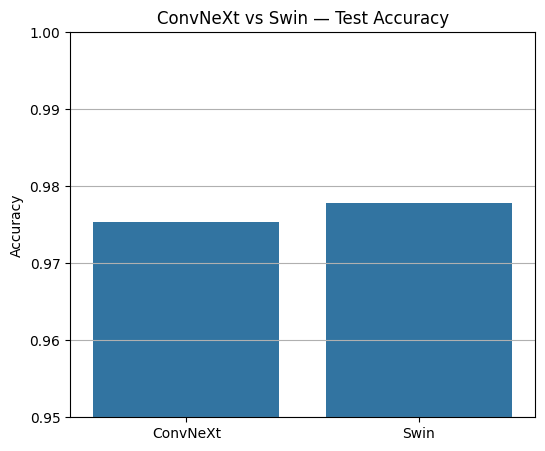

In [ ]:
plt.figure(figsize=(6,5))
models = ["ConvNeXt", "Swin"]
accs = [conv_metrics["Accuracy"], swin_metrics["Accuracy"]]

sns.barplot(x=models, y=accs)
plt.title("ConvNeXt vs Swin — Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.95, 1.0)
plt.grid(True, axis='y')
plt.show()


**Per-Class Accuracy**

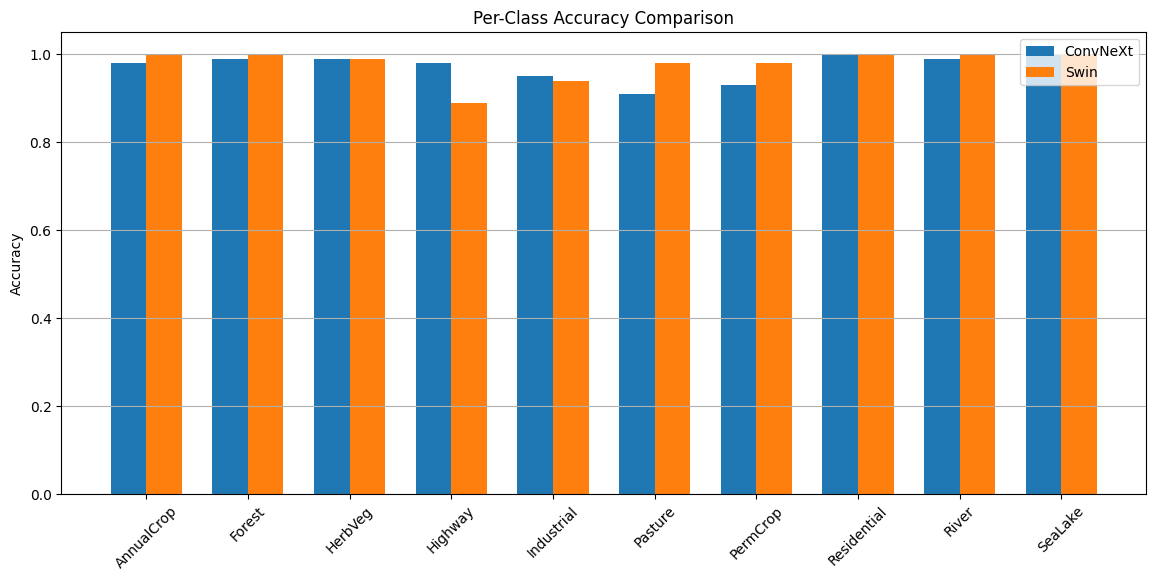

In [ ]:
plt.figure(figsize=(14,6))
x = np.arange(len(classes))
width = 0.35

plt.bar(x - width/2, conv_recall, width=width, label="ConvNeXt")
plt.bar(x + width/2, swin_recall, width=width, label="Swin")

plt.xticks(x, classes, rotation=45)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy Comparison")
plt.grid(axis='y')
plt.legend()
plt.show()


**Per-Class Precision**

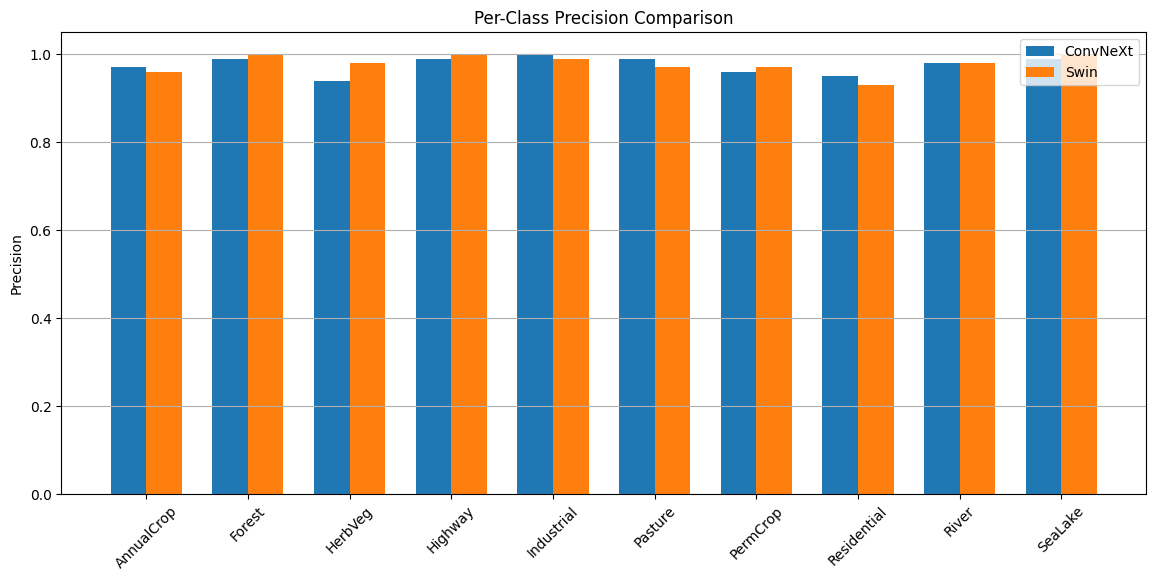

In [ ]:
plt.figure(figsize=(14,6))
x = np.arange(len(classes))
width = 0.35

plt.bar(x - width/2, conv_precision, width=width, label="ConvNeXt")
plt.bar(x + width/2, swin_precision, width=width, label="Swin")

plt.xticks(x, classes, rotation=45)
plt.ylabel("Precision")
plt.title("Per-Class Precision Comparison")
plt.grid(axis='y')
plt.legend()
plt.show()


**Per-Class Recall**

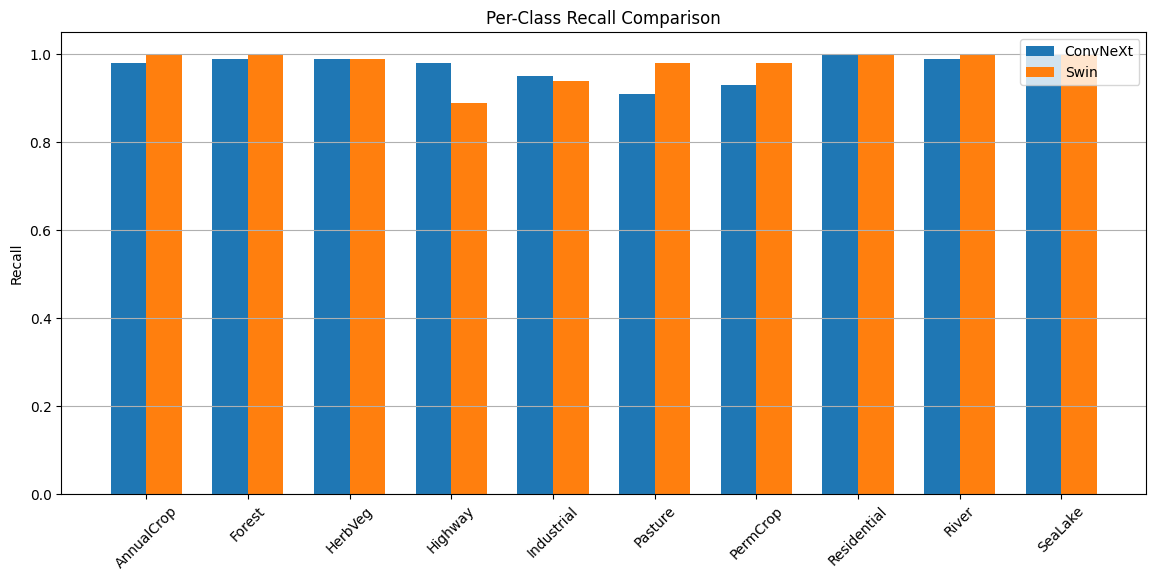

In [ ]:
plt.figure(figsize=(14,6))
x = np.arange(len(classes))
width = 0.35

plt.bar(x - width/2, conv_recall, width=width, label="ConvNeXt")
plt.bar(x + width/2, swin_recall, width=width, label="Swin")

plt.xticks(x, classes, rotation=45)
plt.ylabel("Recall")
plt.title("Per-Class Recall Comparison")
plt.grid(axis='y')
plt.legend()
plt.show()


**Per-Class F1 Score**

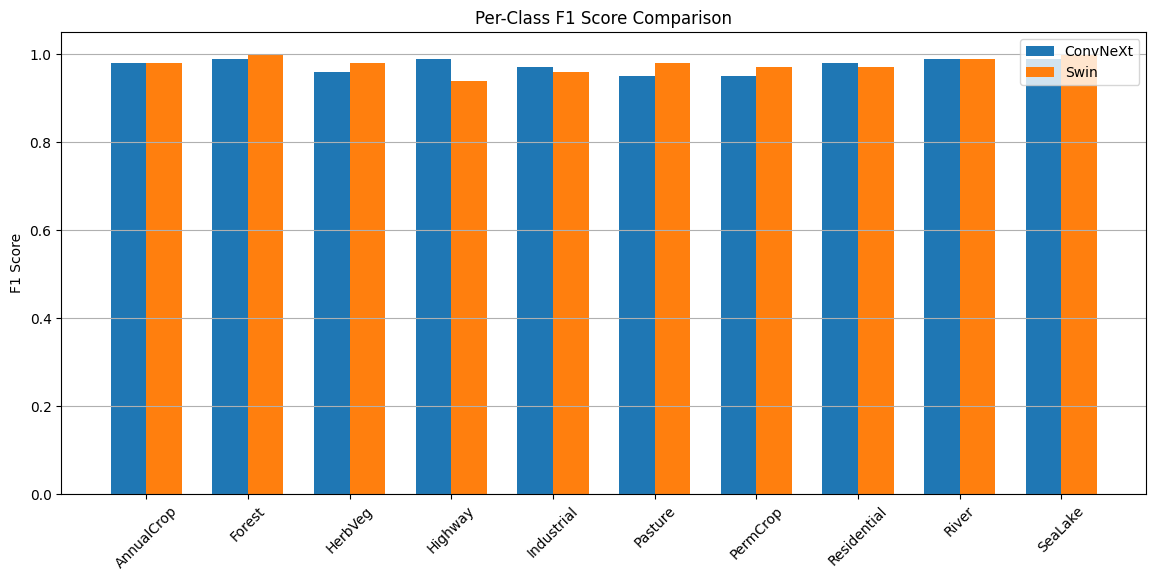

In [ ]:
plt.figure(figsize=(14,6))
x = np.arange(len(classes))
width = 0.35

plt.bar(x - width/2, conv_f1, width=width, label="ConvNeXt")
plt.bar(x + width/2, swin_f1, width=width, label="Swin")

plt.xticks(x, classes, rotation=45)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score Comparison")
plt.grid(axis='y')
plt.legend()
plt.show()


**Overall Metrics Comparison (Macro F1, Weighted F1)**

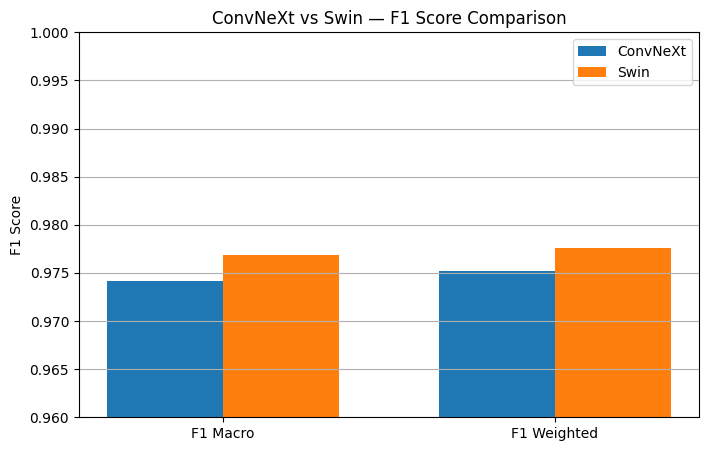

In [ ]:
labels = ["F1 Macro", "F1 Weighted"]
conv_vals = [conv_metrics["F1 Macro"], conv_metrics["F1 Weighted"]]
swin_vals = [swin_metrics["F1 Macro"], swin_metrics["F1 Weighted"]]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - w/2, conv_vals, width=w, label="ConvNeXt")
plt.bar(x + w/2, swin_vals, width=w, label="Swin")
plt.xticks(x, labels)
plt.title("ConvNeXt vs Swin — F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0.96, 1.0)
plt.legend()
plt.grid(True, axis='y')
plt.show()


**Cohen’s Kappa Comparison**

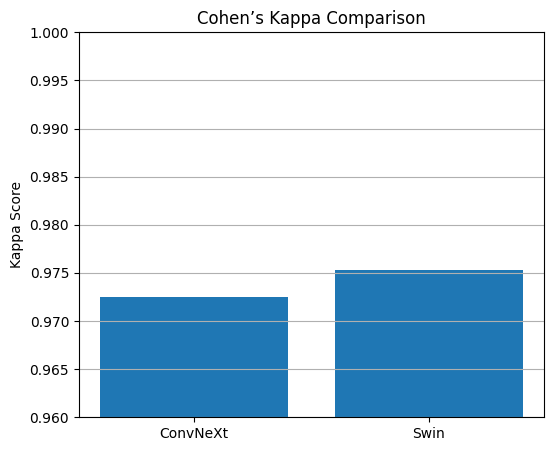

In [ ]:
plt.figure(figsize=(6,5))
plt.bar(["ConvNeXt","Swin"], [conv_metrics["Kappa"], swin_metrics["Kappa"]])
plt.title("Cohen’s Kappa Comparison")
plt.ylabel("Kappa Score")
plt.ylim(0.96, 1.0)
plt.grid(True, axis='y')
plt.show()


**Confusion Metrix:**

**Confusion Matrix for ConvNeXt**

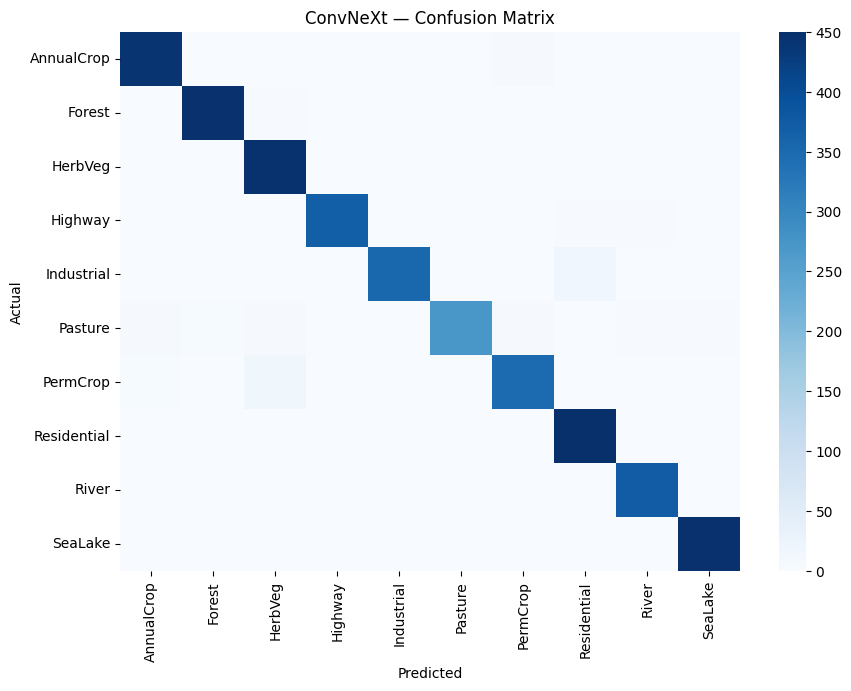

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conv_cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(conv_cm, annot=False, cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("ConvNeXt — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Confusion Matrix for Swin Transformer**

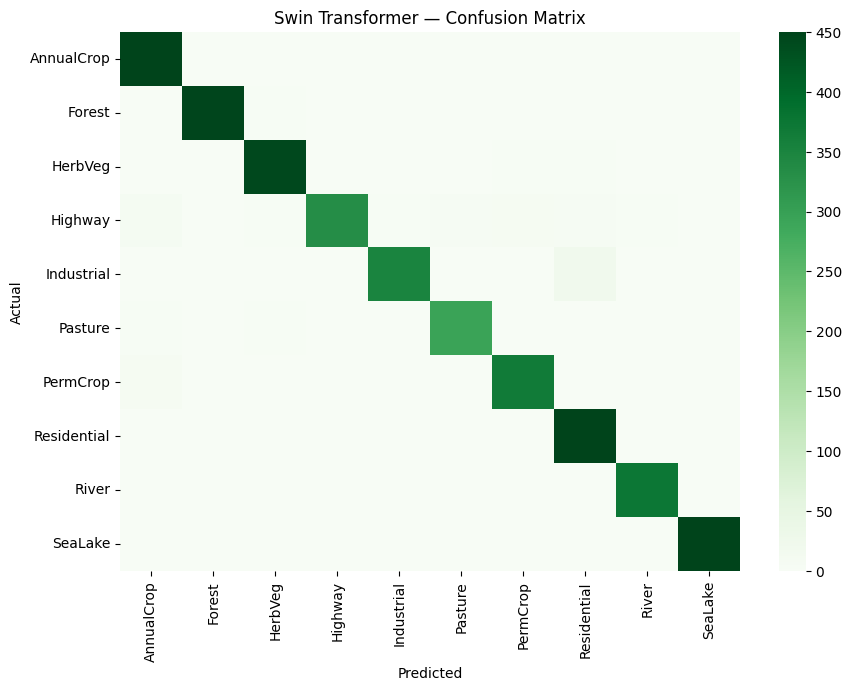

In [ ]:
swin_cm = confusion_matrix(swin_y_true, swin_y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(swin_cm, annot=False, cmap="Greens",
            xticklabels=classes, yticklabels=classes)
plt.title("Swin Transformer — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from google.colab import files

uploaded = files.upload()   # choose your image from your computer


Saving sample.PNG to sample.PNG


In [ ]:
import shutil

uploaded_filename = list(uploaded.keys())[0]

drive_path = "/content/drive/MyDrive/EuroSAT_RealImages/"  # your folder
os.makedirs(drive_path, exist_ok=True)

save_path = drive_path + uploaded_filename
shutil.move(uploaded_filename, save_path)

print("Image saved to:", save_path)


Image saved to: /content/drive/MyDrive/EuroSAT_RealImages/sample.PNG


**Models Testind on Real Image:**

**ConvNext**

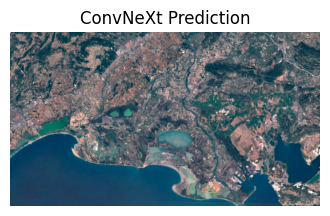

Actual Image Path: /content/drive/MyDrive/EuroSAT_RealImages/sample.PNG
Predicted Class: Residential

Class Probabilities:
Residential       :  91.28%
PermCrop          :   4.39%
SeaLake           :   2.49%
HerbVeg           :   1.04%
River             :   0.37%
Highway           :   0.22%
Forest            :   0.08%
Pasture           :   0.07%
AnnualCrop        :   0.05%
Industrial        :   0.03%


In [ ]:
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

def predict_convnext(img_path):
    img = Image.open(img_path).convert("RGB")

    # preprocess
    tensor = test_tf(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(tensor)
        prob = torch.softmax(out, dim=1)[0].cpu().numpy()

    pred_idx = np.argmax(prob)
    pred_class = classes[pred_idx]

    # show image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("ConvNeXt Prediction")
    plt.show()

    print("Actual Image Path:", img_path)
    print("Predicted Class:", pred_class)
    print("\nClass Probabilities:")
    for cls_name, p in sorted(zip(classes, prob), key=lambda x: x[1], reverse=True):
        print(f"{cls_name:18s}: {p*100:6.2f}%")
predict_convnext(save_path)


**Swin**

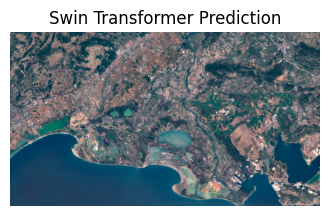

Actual Image Path: /content/drive/MyDrive/EuroSAT_RealImages/sample.PNG
Predicted Class: Residential

Class Probabilities:
Residential       : 100.00%
PermCrop          :   0.00%
SeaLake           :   0.00%
AnnualCrop        :   0.00%
Highway           :   0.00%
Forest            :   0.00%
Industrial        :   0.00%
Pasture           :   0.00%
HerbVeg           :   0.00%
River             :   0.00%


In [ ]:
def predict_swin(img_path):
    img = Image.open(img_path).convert("RGB")

    # preprocess
    tensor = swin_test_tf(img).unsqueeze(0).to(device)

    swin_model.eval()
    with torch.no_grad():
        out = swin_model(tensor)
        prob = torch.softmax(out, dim=1)[0].cpu().numpy()

    pred_idx = np.argmax(prob)
    pred_class = classes[pred_idx]

    # show image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Swin Transformer Prediction")
    plt.show()

    print("Actual Image Path:", img_path)
    print("Predicted Class:", pred_class)
    print("\nClass Probabilities:")
    for cls_name, p in sorted(zip(classes, prob), key=lambda x: x[1], reverse=True):
        print(f"{cls_name:18s}: {p*100:6.2f}%")
predict_swin(save_path)
